## Train a Multimodal Hybrid CNN + Landmark Transformer on 100-Driver Dataset

## 0) Install packages

In [1]:
# %pip install -U pip setuptools wheel
# %pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
# %pip install numpy pandas scikit-learn pillow tqdm matplotlib

## 1) Imports

In [2]:
import os
import json
import math
import random
import time
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights 
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights  

ImageFile.LOAD_TRUNCATED_IMAGES = True

/home/lurpd/DevelopmentWSL2/DistractionAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Config

In [3]:
DATA_ROOT = Path(r"../../Datasets/100-driver")
SETTING = "Traditional-setting"
TIME_OF_DAY = "Day"
CAMERAS = ["Cam1", "Cam2", "Cam3"]
SPLIT_PREFIX = None
IMG_ROOT_OVERRIDE = None
LANDMARK_PATH_OVERRIDE = None

@dataclass
class TrainConfig:
    #training
    epochs: int = 80
    backbone_lr: float =2e-5
    head_lr: float = 3e-4 
    weight_decay: float = 3.5e-2
    batch_size: int = 12
    num_workers: int = 8
    img_size: int = 256 
    warm_epochs: int = 7
    save_every: int = 20
    seed: int = 42
    patience: int = 15

    #transformer
    embed_dim: int = 144
    num_heads: int = 4
    num_layers: int = 3
    ff_dim: int = 448              
    dropout: float = 0.30 

    #MixUp
    mixup_alpha: float = 0.1

    #landmark config
    pose_points: int = 33
    hand_points: int = 21
    face_points: int = 478
    landmark_dims: int = 3
    num_geo_features: int = 23

    safe_drive_weight: float = 2.0

    cam_tag: str = "_".join(CAMERAS)
    out_dir: Path = Path(f"../best_models/100-driver/multimodal_effv2/{cam_tag}_{TIME_OF_DAY}")
    best_name: str = f"hybrid_effv2S_100driver_{cam_tag}_{TIME_OF_DAY}_best.pt"

cfg = TrainConfig()
cfg.out_dir.mkdir(parents=True, exist_ok=True)
print("Config:", cfg)
print("Training cameras:", CAMERAS)

Config: TrainConfig(epochs=80, backbone_lr=2e-05, head_lr=0.0003, weight_decay=0.035, batch_size=12, num_workers=8, img_size=256, warm_epochs=7, save_every=20, seed=42, patience=15, embed_dim=144, num_heads=4, num_layers=3, ff_dim=448, dropout=0.3, mixup_alpha=0.1, pose_points=33, hand_points=21, face_points=478, landmark_dims=3, num_geo_features=23, safe_drive_weight=2.0, cam_tag='Cam1_Cam2_Cam3', out_dir=PosixPath('../best_models/100-driver/multimodal_effv2/Cam1_Cam2_Cam3_Day'), best_name='hybrid_effv2S_100driver_Cam1_Cam2_Cam3_Day_best.pt')
Training cameras: ['Cam1', 'Cam2', 'Cam3']


## 3) Utils

In [4]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

def cuda_sanity_check():
    print("torch:", torch.__version__)
    try:
        import torchvision
        print("torchvision:", torchvision.__version__)
    except Exception as e:
        print("torchvision import failed:", e)
    print("torch.version.cuda:", torch.version.cuda)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        idx = torch.cuda.current_device()
        props = torch.cuda.get_device_properties(idx)
        print("GPU:", props.name)
        print("Total VRAM (GB):", round(props.total_memory / (1024**3), 2))

def parse_split_file(txt_path: Path):
    records = []
    with open(txt_path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            records.append({"sample_id": parts[0], "rel_path": parts[1], "label": int(parts[2])})
    return records

def infer_class_names(records):
    names_by_label = defaultdict(list)
    for rec in records:
        rel = Path(rec["rel_path"])
        folder_name = rel.parent.name if rel.parent.name else f"class_{rec['label']}"
        names_by_label[rec["label"]].append(folder_name)
    max_label = max(r["label"] for r in records)
    ordered_names = []
    for i in range(max_label + 1):
        if i in names_by_label:
            ordered_names.append(Counter(names_by_label[i]).most_common(1)[0][0])
        else:
            ordered_names.append(f"class_{i}")
    return ordered_names

def normalize_lookup_key(value):
    if value is None:
        return None
    text = str(value).strip()
    return text.replace("\\", "/") if text else None

def register_entry(lookup, key, entry):
    norm = normalize_lookup_key(key)
    if norm is None:
        return
    lookup.setdefault(norm, entry)
    p = Path(norm)
    lookup.setdefault(p.as_posix(), entry)
    lookup.setdefault(p.name, entry)
    lookup.setdefault(p.stem, entry)

def load_landmark_lookup(landmark_path):
    if landmark_path is None or not Path(landmark_path).exists():
        return {}
    with open(landmark_path, "r", encoding="utf-8") as f:
        raw = json.load(f)
    lookup = {}
    if isinstance(raw, dict):
        if all(isinstance(v, dict) for v in raw.values()):
            for key, value in raw.items():
                register_entry(lookup, key, value)
                if isinstance(value, dict):
                    for ek in ("rel_path","image_path","img_path","path","sample_id","id","file_name","filename"):
                        register_entry(lookup, value.get(ek), value)
    elif isinstance(raw, list):
        for item in raw:
            if not isinstance(item, dict):
                continue
            for ek in ("rel_path","image_path","img_path","path","sample_id","id","file_name","filename"):
                register_entry(lookup, item.get(ek), item)
    return lookup

def resolve_landmark_path(override_path, data_root, time_of_day, camera):
    candidates = []
    if override_path:
        candidates.append(Path(override_path))
    cl = camera.lower(); tl = time_of_day.lower()
    candidates.extend([
        data_root / f"driver_landmarks_{tl}_{cl}.json",
        data_root / f"driver_landmarks_{tl}_{camera}.json",
        data_root / f"driver_landmarks_{cl}_{tl}.json",
        data_root / f"driver_landmarks_{tl}.json",
        data_root / "driver_landmarks.json",
    ])
    for c in candidates:
        if c.exists():
            return c
    return None

seed_everything(cfg.seed)
cuda_sanity_check()

torch: 2.10.0+cu130
torchvision: 0.25.0+cu130
torch.version.cuda: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 5070
Total VRAM (GB): 11.94


## 4) Parse split files and define training directories

In [5]:
# Load and merge split files from all cameras
# Each camera has its own split files and image directory.
# We prefix each record's rel_path with "CamN/" so that all records
# resolve correctly from the shared parent: DATA_ROOT / TIME_OF_DAY /

all_train_records = []
all_val_records = []

for cam in CAMERAS:
    split_root = DATA_ROOT / "data-splits" / "data-splits" / SETTING / TIME_OF_DAY / cam

    if SPLIT_PREFIX is not None:
        prefix = SPLIT_PREFIX
    elif SETTING.lower() == "traditional-setting":
        prefix = TIME_OF_DAY[0] + cam[len(cam) - 1]  # e.g. "D1", "D2", "D3"
    else:
        raise ValueError("Set SPLIT_PREFIX explicitly for non-traditional settings.")

    train_file = split_root / (prefix + "_train.txt")
    val_file = split_root / (prefix + "_val.txt")
    print(f"  {cam}: train={train_file.name}, val={val_file.name}")

    for rec in parse_split_file(train_file):
        # Prefix rel_path so it resolves from DATA_ROOT/Day/
        rec["rel_path"] = f"{cam}/{rec['rel_path']}"
        rec["camera"] = cam
        all_train_records.append(rec)

    for rec in parse_split_file(val_file):
        rec["rel_path"] = f"{cam}/{rec['rel_path']}"
        rec["camera"] = cam
        all_val_records.append(rec)

train_records = all_train_records
val_records = all_val_records

CLASS_NAMES = infer_class_names(train_records + val_records)
NUM_CLASSES = len(CLASS_NAMES)
print(f"\nClasses ({NUM_CLASSES}):", CLASS_NAMES)
print(f"Train samples: {len(train_records)}, Val samples: {len(val_records)}")
for cam in CAMERAS:
    n_train = sum(1 for r in train_records if r["camera"] == cam)
    n_val = sum(1 for r in val_records if r["camera"] == cam)
    print(f"  {cam}: {n_train} train, {n_val} val")

# Image root is the parent directory containing all camera folders
IMG_ROOT = DATA_ROOT / TIME_OF_DAY
print(f"\nImage root: {IMG_ROOT}")

# Load and merge landmark lookups from all cameras
LANDMARK_LOOKUP = {}
for cam in CAMERAS:
    lm_path = resolve_landmark_path(LANDMARK_PATH_OVERRIDE, DATA_ROOT, TIME_OF_DAY, cam)
    if lm_path is not None:
        cam_lookup = load_landmark_lookup(lm_path)
        # Re-key entries with camera prefix to match the prefixed rel_paths
        for key, value in list(cam_lookup.items()):
            prefixed_key = f"{cam}/{key}"
            LANDMARK_LOOKUP[prefixed_key] = value
        # Also keep original keys for fallback matching
        LANDMARK_LOOKUP.update(cam_lookup)
        print(f"  {cam}: loaded {len(cam_lookup)} landmark entries from {lm_path.name}")
    else:
        print(f"  {cam}: no landmark file found")
print(f"Combined landmark lookup: {len(LANDMARK_LOOKUP)} entries")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

  Cam1: train=D1_train.txt, val=D1_val.txt
  Cam2: train=D2_train.txt, val=D2_val.txt
  Cam3: train=D3_train.txt, val=D3_val.txt

Classes (22): ['C1_Drive_Safe', 'C2_Sleep', 'C3_Yawning', 'C4_Talk_Left', 'C5_Talk_Right', 'C6_Text_Left', 'C7_Text_Right', 'C8_Make_Up', 'C9_Look_Left', 'C10_Look_Right', 'C11_Look_Up', 'C12_Look_Down', 'C13_Smoke_Left', 'C14_Smoke_Right', 'C15_Smoke_Mouth', 'C16_Eat_Left', 'C17_Eat_Right', 'C18_Operate_Radio', 'C19_Operate_GPS', 'C20_Reach_Behind', 'C21_Leave_Steering_Wheel', 'C22_Talk_to_Passenger']
Train samples: 134478, Val samples: 12097
  Cam1: 45388 train, 4334 val
  Cam2: 42959 train, 3810 val
  Cam3: 46131 train, 3953 val

Image root: ../../Datasets/100-driver/Day
  Cam1: loaded 182733 landmark entries from driver_landmarks_day_cam1.json
  Cam2: loaded 172963 landmark entries from driver_landmarks_day_cam2.json
  Cam3: loaded 184371 landmark entries from driver_landmarks_day_cam3.json
Combined landmark lookup: 1072070 entries
Device: cuda


## 5) Transforms

In [6]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.RandomResizedCrop(
        cfg.img_size, scale=(0.80, 1.0), ratio=(0.9, 1.1),
        interpolation=InterpolationMode.BILINEAR,
    ),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.15, hue=0.03),
    transforms.RandomRotation(12),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])

val_tfms = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

print("img_size:", cfg.img_size)

img_size: 256


## 6) Geometric Feature Extraction + Dataset

**Design rationale:** The front-left camera (Cam1) reliably captures the driver's face but hands are frequently occluded by the steering wheel, seatbelt, and dashboard. Therefore geometric features are organized into 3 reliability tiers:
- **Tier 1 (face — always available):** head pose (yaw/pitch/roll), EAR, MAR, nose position → 10 features
- **Tier 2 (pose — usually available):** shoulder angle, body lean, wrist elevation, head-shoulder offset → 7 features  
- **Tier 3 (hands — often missing):** hand-face distance, wrist separation, hand presence flags → 6 features

Each tier gets its own transformer token with validity-based gating so missing data degrades gracefully.

In [7]:
# ---------------------------------------------------------------------------
# Geometric Feature Extraction — Face-focused with graceful degradation
# ---------------------------------------------------------------------------

class GeometricFeatureExtractor:
    # MediaPipe face mesh indices
    NOSE_TIP = 1; CHIN = 152; FOREHEAD = 10
    LEFT_EYE_OUTER = 33; RIGHT_EYE_OUTER = 263
    LEFT_EYE_TOP = 159; LEFT_EYE_BOTTOM = 145
    LEFT_EYE_LEFT = 33; LEFT_EYE_RIGHT = 133
    RIGHT_EYE_TOP = 386; RIGHT_EYE_BOTTOM = 374
    RIGHT_EYE_LEFT = 362; RIGHT_EYE_RIGHT = 263
    MOUTH_TOP = 13; MOUTH_BOTTOM = 14; MOUTH_LEFT = 61; MOUTH_RIGHT = 291

    # MediaPipe pose indices
    POSE_NOSE = 0
    POSE_LEFT_SHOULDER = 11; POSE_RIGHT_SHOULDER = 12
    POSE_LEFT_ELBOW = 13; POSE_RIGHT_ELBOW = 14
    POSE_LEFT_WRIST = 15; POSE_RIGHT_WRIST = 16
    POSE_LEFT_HIP = 23; POSE_RIGHT_HIP = 24

    # Hand indices
    HAND_WRIST = 0; HAND_INDEX_TIP = 8; HAND_MIDDLE_TIP = 12

    @staticmethod
    def _g(pts, idx, valid, d=3):
        if idx < len(pts) and idx < len(valid) and valid[idx]:
            return pts[idx, :d]
        return None

    @staticmethod
    def _dist(a, b):
        if a is None or b is None: return 0.0
        return float(np.linalg.norm(a - b))

    @staticmethod
    def _ratio(top, bottom, left, right, default=0.3):
        v = GeometricFeatureExtractor._dist(top, bottom)
        h = GeometricFeatureExtractor._dist(left, right)
        return v / h if h > 1e-6 else default

    @classmethod
    def compute(cls, face_pts, face_v, pose_pts, pose_v,
                left_hand_pts, left_v, right_hand_pts, right_v):
        g = cls._g
        feats = []
        vmask = []

        # ═══════════ TIER 1: Face features (10) ═══════════
        nose = g(face_pts, cls.NOSE_TIP, face_v, 3)
        chin = g(face_pts, cls.CHIN, face_v, 3)
        forehead = g(face_pts, cls.FOREHEAD, face_v, 3)
        l_eye = g(face_pts, cls.LEFT_EYE_OUTER, face_v, 3)
        r_eye = g(face_pts, cls.RIGHT_EYE_OUTER, face_v, 3)
        has_face = nose is not None and chin is not None

        # 1. Yaw (head left-right turn)
        if has_face and l_eye is not None and r_eye is not None:
            eye_mid_x = (l_eye[0] + r_eye[0]) / 2
            feats.append(float(nose[0] - eye_mid_x)); vmask.append(True)
        else:
            feats.append(0.0); vmask.append(False)

        # 2. Pitch (head up-down tilt)
        if has_face and forehead is not None:
            up = cls._dist(nose, forehead); dn = cls._dist(nose, chin)
            feats.append((dn - up) / max(dn + up, 1e-6)); vmask.append(True)
        else:
            feats.append(0.0); vmask.append(False)

        # 3. Roll (head tilt sideways)
        if l_eye is not None and r_eye is not None:
            feats.append(float(np.arctan2(r_eye[1]-l_eye[1], r_eye[0]-l_eye[0]+1e-8)))
            vmask.append(True)
        else:
            feats.append(0.0); vmask.append(False)

        # 4-6. Nose position (x, y, z)
        if nose is not None:
            feats.extend([float(nose[0]), float(nose[1]), float(nose[2]) if len(nose)>2 else 0.0])
            vmask.extend([True, True, True])
        else:
            feats.extend([0.5, 0.5, 0.0]); vmask.extend([False, False, False])

        # 7-8. Eye Aspect Ratios (left, right)
        for side_top, side_bot, side_l, side_r in [
            (cls.LEFT_EYE_TOP, cls.LEFT_EYE_BOTTOM, cls.LEFT_EYE_LEFT, cls.LEFT_EYE_RIGHT),
            (cls.RIGHT_EYE_TOP, cls.RIGHT_EYE_BOTTOM, cls.RIGHT_EYE_LEFT, cls.RIGHT_EYE_RIGHT),
        ]:
            ear = cls._ratio(g(face_pts,side_top,face_v,2), g(face_pts,side_bot,face_v,2),
                             g(face_pts,side_l,face_v,2), g(face_pts,side_r,face_v,2), 0.3)
            feats.append(ear)
            vmask.append(g(face_pts, side_top, face_v) is not None)

        # 9. Mouth Aspect Ratio
        mar = cls._ratio(g(face_pts,cls.MOUTH_TOP,face_v,2), g(face_pts,cls.MOUTH_BOTTOM,face_v,2),
                         g(face_pts,cls.MOUTH_LEFT,face_v,2), g(face_pts,cls.MOUTH_RIGHT,face_v,2), 0.1)
        feats.append(mar)
        vmask.append(g(face_pts, cls.MOUTH_TOP, face_v) is not None)

        # 10. Face width-to-height ratio (face shape/orientation indicator)
        if l_eye is not None and r_eye is not None and has_face:
            face_w = cls._dist(l_eye[:2], r_eye[:2])
            face_h = cls._dist(forehead[:2] if forehead is not None else nose[:2], chin[:2])
            feats.append(face_w / max(face_h, 1e-6)); vmask.append(True)
        else:
            feats.append(0.6); vmask.append(False)

        # ═══════════ TIER 2: Pose features (7) ═══════════
        l_sh = g(pose_pts, cls.POSE_LEFT_SHOULDER, pose_v, 3)
        r_sh = g(pose_pts, cls.POSE_RIGHT_SHOULDER, pose_v, 3)
        l_wr = g(pose_pts, cls.POSE_LEFT_WRIST, pose_v, 3)
        r_wr = g(pose_pts, cls.POSE_RIGHT_WRIST, pose_v, 3)
        l_hip = g(pose_pts, cls.POSE_LEFT_HIP, pose_v, 3)
        r_hip = g(pose_pts, cls.POSE_RIGHT_HIP, pose_v, 3)
        p_nose = g(pose_pts, cls.POSE_NOSE, pose_v, 3)

        sh_w = cls._dist(l_sh, r_sh) if l_sh is not None and r_sh is not None else 1.0
        if sh_w < 1e-4: sh_w = 1.0

        # 11. Shoulder roll angle
        if l_sh is not None and r_sh is not None:
            feats.append(float(np.arctan2(r_sh[1]-l_sh[1], r_sh[0]-l_sh[0]+1e-8)))
            vmask.append(True)
        else:
            feats.append(0.0); vmask.append(False)

        # 12. Body lean (shoulder vs hip midpoint)
        if l_sh is not None and r_sh is not None and l_hip is not None and r_hip is not None:
            sh_mid = (l_sh[0]+r_sh[0])/2; hip_mid = (l_hip[0]+r_hip[0])/2
            feats.append((sh_mid - hip_mid) / sh_w); vmask.append(True)
        else:
            feats.append(0.0); vmask.append(False)

        # 13-14. Left/Right wrist elevation relative to shoulder
        for wr, sh in [(l_wr, l_sh), (r_wr, r_sh)]:
            if wr is not None and sh is not None:
                feats.append((sh[1] - wr[1]) / sh_w); vmask.append(True)
            else:
                feats.append(0.0); vmask.append(False)

        # 15-16. Left/Right wrist-to-face distance
        ref_nose = nose if nose is not None else p_nose
        for wr in [l_wr, r_wr]:
            if wr is not None and ref_nose is not None:
                feats.append(cls._dist(wr[:2], ref_nose[:2]) / sh_w); vmask.append(True)
            else:
                feats.append(2.0); vmask.append(False)

        # 17. Head-to-shoulder vertical offset (looking down indicator)
        if p_nose is not None and l_sh is not None and r_sh is not None:
            sh_mid_y = (l_sh[1]+r_sh[1])/2
            feats.append((p_nose[1] - sh_mid_y) / sh_w); vmask.append(True)
        else:
            feats.append(-1.0); vmask.append(False)

        # ═══════════ TIER 3: Hand features (6) ═══════════
        # 18-19. Left/right hand presence (binary)
        lh_w = g(left_hand_pts, cls.HAND_WRIST, left_v, 2)
        rh_w = g(right_hand_pts, cls.HAND_WRIST, right_v, 2)
        feats.append(1.0 if lh_w is not None else 0.0); vmask.append(True)
        feats.append(1.0 if rh_w is not None else 0.0); vmask.append(True)

        # 20. Wrist separation (hands together = holding phone)
        if l_wr is not None and r_wr is not None:
            feats.append(cls._dist(l_wr[:2], r_wr[:2]) / sh_w); vmask.append(True)
        else:
            feats.append(1.0); vmask.append(False)

        # 21-22. Left/right hand openness (wrist-to-fingertip distance)
        for h_pts, h_v in [(left_hand_pts, left_v), (right_hand_pts, right_v)]:
            hw = g(h_pts, cls.HAND_WRIST, h_v, 2)
            hm = g(h_pts, cls.HAND_MIDDLE_TIP, h_v, 2)
            if hw is not None and hm is not None:
                feats.append(cls._dist(hw, hm)); vmask.append(True)
            else:
                feats.append(0.0); vmask.append(False)

        # 23. Index finger tip distance between hands (bimanual activity)
        li = g(left_hand_pts, cls.HAND_INDEX_TIP, left_v, 2)
        ri = g(right_hand_pts, cls.HAND_INDEX_TIP, right_v, 2)
        if li is not None and ri is not None:
            feats.append(cls._dist(li, ri)); vmask.append(True)
        else:
            feats.append(0.0); vmask.append(False)

        return np.array(feats, dtype=np.float32), np.array(vmask, dtype=bool)


# ---------------------------------------------------------------------------
# Dataset
# ---------------------------------------------------------------------------

class HybridMultimodalDataset(Dataset):
    def __init__(self, records, img_root, transform=None, landmark_path=None,
                 pose_points=33, face_points=478, hand_points=21,
                 landmark_dims=3, num_geo_features=23, landmark_lookup=None):
        self.records = list(records)
        self.img_root = Path(img_root)
        self.transform = transform
        self.fp = face_points; self.hp = hand_points; self.pp = pose_points
        self.ld = landmark_dims; self.ngf = num_geo_features
        
        # Load landmarks
        if landmark_lookup is not None:
            lm = landmark_lookup
        else:
            lm = load_landmark_lookup(landmark_path)
        
        # Pre-compute ALL geometric features upfront
        # This avoids copying the huge dict into every worker process
        geo_ext = GeometricFeatureExtractor()
        self.all_geo = torch.zeros(len(self.records), num_geo_features)
        self.all_gv = torch.zeros(len(self.records), num_geo_features)
        
        n_found = 0
        for idx in range(len(self.records)):
            entry = self._lookup_from_dict(lm, self.records[idx])
            pp, pv, fp, fv, lp, lv, rp, rv = self._extract_landmarks_static(
                entry, self.pp, self.fp, self.hp, self.ld)
            geo, gv = geo_ext.compute(fp, fv, pp, pv, lp, lv, rp, rv)
            if len(geo) < num_geo_features:
                geo = np.pad(geo, (0, num_geo_features - len(geo)))
                gv = np.pad(gv, (0, num_geo_features - len(gv)))
            else:
                geo = geo[:num_geo_features]; gv = gv[:num_geo_features]
            self.all_geo[idx] = torch.from_numpy(geo)
            self.all_gv[idx] = torch.from_numpy(gv.astype(np.float32))
            if gv.any(): n_found += 1
        
        print(f"Pre-computed geo features for {len(self.records)} samples "
              f"({n_found} with landmarks, {len(self.records)-n_found} zero-padded)")
        # Free the landmark dict — workers never need it
        del lm

    def __len__(self): return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = Image.open(self.img_root / rec["rel_path"]).convert("RGB")
        x = self.transform(img) if self.transform else transforms.ToTensor()(img)
        return (x, self.all_geo[idx], self.all_gv[idx]), int(rec["label"])

    @staticmethod
    def _lookup_from_dict(lm, rec):
        for key in [rec["rel_path"], Path(rec["rel_path"]).as_posix(),
                     Path(rec["rel_path"]).name, Path(rec["rel_path"]).stem, rec["sample_id"]]:
            k = normalize_lookup_key(key)
            if k in lm: return lm[k]
        return None

    @staticmethod
    def _extract_landmarks_static(entry, pp, fp, hp, ld):
        z = lambda n: (np.zeros((n, ld), dtype=np.float32), np.zeros(n, dtype=bool))
        if entry is None:
            return z(pp) + z(fp) + z(hp) + z(hp)
        c = entry.get("landmarks", entry) if isinstance(entry, dict) else entry
        if not isinstance(c, dict):
            return z(pp) + z(fp) + z(hp) + z(hp)
        
        def coerce(raw, max_pts):
            pts = np.zeros((max_pts, ld), dtype=np.float32)
            v = np.zeros(max_pts, dtype=bool)
            if raw is None: return pts, v
            if isinstance(raw, dict):
                if "landmarks" in raw: raw = raw["landmarks"]
                elif any(k in raw for k in ("left","right")): return pts, v
            processed = []
            if isinstance(raw, (list, tuple)):
                if len(raw) > 0 and isinstance(raw[0], dict):
                    processed = [[float(p.get("x",0)), float(p.get("y",0)), float(p.get("z",0))] for p in raw]
                elif len(raw) > 0 and isinstance(raw[0], (list, tuple)):
                    processed = [[float(x) for x in p[:ld]] for p in raw]
                else:
                    flat = [float(x) for x in raw]
                    usable = (len(flat)//ld)*ld
                    if usable: processed = np.array(flat[:usable]).reshape(-1, ld).tolist()
            if processed:
                arr = np.array(processed[:max_pts], dtype=np.float32)
                n = min(max_pts, arr.shape[0])
                pts[:n, :min(arr.shape[1], ld)] = arr[:n, :ld]
                v[:n] = True
            return pts, v
        
        pose_r = c.get("pose") or c.get("pose_landmarks")
        face_r = c.get("face") or c.get("face_landmarks") or c.get("face_mesh")
        left_r = c.get("left_hand") or c.get("left_hand_landmarks") or c.get("hand_left")
        right_r = c.get("right_hand") or c.get("right_hand_landmarks") or c.get("hand_right")
        hands = c.get("hands") or c.get("hand") or c.get("hand_landmarks")
        if isinstance(hands, dict):
            left_r = left_r or hands.get("left")
            right_r = right_r or hands.get("right")
        return coerce(pose_r, pp) + coerce(face_r, fp) + coerce(left_r, hp) + coerce(right_r, hp)


# Build datasets
train_ds = HybridMultimodalDataset(
    train_records, IMG_ROOT, train_tfms,
    pose_points=cfg.pose_points, face_points=cfg.face_points,
    hand_points=cfg.hand_points, landmark_dims=cfg.landmark_dims,
    num_geo_features=cfg.num_geo_features, landmark_lookup=LANDMARK_LOOKUP)
val_ds = HybridMultimodalDataset(
    val_records, IMG_ROOT, val_tfms,
    pose_points=cfg.pose_points, face_points=cfg.face_points,
    hand_points=cfg.hand_points, landmark_dims=cfg.landmark_dims,
    num_geo_features=cfg.num_geo_features, landmark_lookup=LANDMARK_LOOKUP)

pin = (device.type == "cuda")
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
    num_workers=cfg.num_workers, pin_memory=pin, persistent_workers=(cfg.num_workers>0), prefetch_factor=4)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=pin, persistent_workers=(cfg.num_workers>0), prefetch_factor=4)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")
t0 = time.time()
batch = next(iter(train_loader))
(si, sg, sv), sl = batch
print(f"Batch: img {si.shape}, geo {sg.shape}, labels {sl.shape} in {time.time()-t0:.2f}s")

Pre-computed geo features for 134478 samples (134478 with landmarks, 0 zero-padded)
Pre-computed geo features for 12097 samples (12097 with landmarks, 0 zero-padded)
Train: 134478, Val: 12097
Batch: img torch.Size([12, 3, 256, 256]), geo torch.Size([12, 23]), labels torch.Size([12]) in 1.01s


## 6b) Landmark Diagnostic

In [8]:
# Check what percentage of samples have valid landmarks per tier
face_ok = pose_ok = hand_ok = any_ok = 0
N = min(2000, len(train_ds))
for i in range(N):
    (_, geo, gv), _ = train_ds[i]
    if gv[:10].any(): face_ok += 1
    if gv[10:17].any(): pose_ok += 1
    if gv[17:].any(): hand_ok += 1
    if gv.any(): any_ok += 1
print(f"Landmark validity ({N} samples):")
print(f"  Face (tier 1):  {face_ok}/{N} = {face_ok/N:.1%}")
print(f"  Pose (tier 2):  {pose_ok}/{N} = {pose_ok/N:.1%}")
print(f"  Hand (tier 3):  {hand_ok}/{N} = {hand_ok/N:.1%}")
print(f"  Any landmark:   {any_ok}/{N} = {any_ok/N:.1%}")

Landmark validity (2000 samples):
  Face (tier 1):  2000/2000 = 100.0%
  Pose (tier 2):  2000/2000 = 100.0%
  Hand (tier 3):  2000/2000 = 100.0%
  Any landmark:   2000/2000 = 100.0%


## 7) Model

In [9]:
class HybridCNNLandmarkTransformer(nn.Module):
    def __init__(self, num_classes, num_geo_features=23, embed_dim=128,
                 num_heads=4, num_layers=3, ff_dim=384, dropout=0.30):
        super().__init__()
        self.embed_dim = embed_dim

        #image encoder EfficientNetV2 S
        self.image_encoder = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.DEFAULT)
        img_out = self.image_encoder.classifier[1].in_features
        self.image_encoder.classifier = nn.Identity()

        for p in self.image_encoder.features.parameters():
            p.requires_grad = False
        for block in self.image_encoder.features[-3:]:
            for p in block.parameters():
                p.requires_grad = True

        #3x3 spatial pooling (9 image tokens)
        self.num_img_tok = 9
        self.img_pool = nn.AdaptiveAvgPool2d((3, 3))
        self.img_proj = nn.Sequential(
            nn.Linear(img_out, embed_dim), nn.LayerNorm(embed_dim), nn.GELU(), nn.Dropout(dropout))
        self.img_pos = nn.Parameter(torch.zeros(1, self.num_img_tok, embed_dim))

        #learnable class temp
        self.class_temp = nn.Parameter(torch.ones(num_classes))

        #geometric feature encoders
        self.tier_sizes = [10, 7, 6]
        self.geo_encoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(s, embed_dim), nn.LayerNorm(embed_dim),
                nn.GELU(), nn.Dropout(dropout),
            ) for s in self.tier_sizes
        ])
        self.geo_pos = nn.Parameter(torch.zeros(1, 3, embed_dim))

        #type embeddings
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.img_type = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.geo_type = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.cls_type = nn.Parameter(torch.zeros(1, 1, embed_dim))

        #transformer
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        #classifier head
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 384), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(384, num_classes))

        self._init_params()

    def _init_params(self):
        for p in [self.cls_token, self.img_pos, self.geo_pos,
                   self.img_type, self.geo_type, self.cls_type]:
            nn.init.normal_(p, std=0.02)

    def forward(self, images, geo_feats, geo_valid):
        B = images.size(0)

        #image tokens
        fm = self.image_encoder.features(images)
        fm = self.img_pool(fm)
        it = fm.flatten(2).transpose(1, 2)
        it = self.img_proj(it) + self.img_pos + self.img_type

        #geo tokens
        gt = []
        off = 0
        for i, s in enumerate(self.tier_sizes):
            chunk = geo_feats[:, off:off+s]
            valid_chunk = geo_valid[:, off:off+s]
            tok = self.geo_encoders[i](chunk)
            tier_v = valid_chunk.mean(dim=1, keepdim=True)
            tok = tok * (0.3 + 0.7 * tier_v)
            gt.append(tok.unsqueeze(1))
            off += s
        gt = torch.cat(gt, dim=1) + self.geo_pos + self.geo_type

        #CLS token
        cls = self.cls_token.expand(B, -1, -1) + self.cls_type

        #assemble tokens
        tokens = torch.cat([cls, it, gt], dim=1)
        encoded = self.transformer(tokens)

        #dual pooling: CLS + average of all tokens
        cls_out = encoded[:, 0]
        avg_out = encoded[:, 1:].mean(dim=1)
        combined = cls_out + 0.5 * avg_out

        logits = self.head(combined)
        logits = logits * self.class_temp
        return logits


def build_model(num_classes, device):
    m = HybridCNNLandmarkTransformer(
        num_classes, cfg.num_geo_features, cfg.embed_dim,
        cfg.num_heads, cfg.num_layers, cfg.ff_dim, cfg.dropout).to(device)
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total = sum(p.numel() for p in m.parameters())
    print(f"Trainable: {trainable:,} / {total:,}")
    return m

model = build_model(NUM_CLASSES, device)

Trainable: 19,253,172 / 21,074,748


/tmp/ipykernel_1404/3774937895.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


## 8) Training utilities

In [10]:
# --- Class-weighted loss with safe driving boost ---
label_counts = Counter(r["label"] for r in train_records)
total_samples = sum(label_counts.values())
class_weights = torch.tensor([
    total_samples / (NUM_CLASSES * label_counts.get(i, 1))
    for i in range(NUM_CLASSES)
], dtype=torch.float32).to(device)
class_weights = class_weights.clamp(max=3.0)

class_weights[0] = cfg.safe_drive_weight

print("Class weights:", class_weights.cpu().numpy().round(2))
print(f"  Drive_Safe weight: {class_weights[0].item():.2f} (boosted from {total_samples / (NUM_CLASSES * label_counts.get(0, 1)):.2f})")

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# --- Layer-wise learning rate decay for EfficientNetV2-S ---
# Deeper backbone layers get progressively smaller learning rates
# This prevents catastrophic forgetting of pretrained features
lr_decay = 0.75
backbone_groups = []
for i, block in enumerate(model.image_encoder.features):
    params = list(block.parameters())
    if not any(p.requires_grad for p in params):
        continue  # skip frozen blocks
    lr_scale = lr_decay ** (len(model.image_encoder.features) - 1 - i)
    backbone_groups.append({
        "params": [p for p in params if p.requires_grad],
        "lr": cfg.backbone_lr * lr_scale,
        "name": f"backbone_block_{i}",
    })

head_params = []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if "image_encoder.features" in name:
        continue  # already in backbone_groups
    head_params.append(p)

param_groups = backbone_groups + [{"params": head_params, "lr": cfg.head_lr, "name": "head"}]

# Print parameter group summary
for pg in param_groups:
    n = sum(p.numel() for p in pg["params"])
    print(f"  {pg.get('name','?'):20s}: {n:>10,} params, lr={pg['lr']:.2e}")

optimizer = torch.optim.AdamW(param_groups, weight_decay=cfg.weight_decay)

# Cosine annealing
train_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cfg.epochs - cfg.warm_epochs, eta_min=1e-6)

class WarmUpLR(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, total_iters, last_epoch=-1):
        self.total_iters = total_iters
        super().__init__(optimizer, last_epoch)
    def get_lr(self):
        return [base_lr * self.last_epoch / (self.total_iters + 1e-8) for base_lr in self.base_lrs]

warmup_scheduler = WarmUpLR(optimizer, cfg.warm_epochs * len(train_loader))

# MixUp
def mixup_data(x, y, alpha=0.2):
    if alpha <= 0: return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

# Training loop
def train_one_epoch(epoch):
    model.train()
    loss_sum = 0.0
    correct = 0
    start = time.time()

    for batch in tqdm(train_loader, desc=f"train {epoch}", leave=False):
        (images, geo, gv), labels = batch
        images = images.to(device, non_blocking=True)
        geo = geo.to(device, non_blocking=True)
        gv = gv.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        use_mixup = (random.random() < 0.3) and (epoch > cfg.warm_epochs)
        if use_mixup:
            images, labels_a, labels_b, lam = mixup_data(images, labels, cfg.mixup_alpha)

        optimizer.zero_grad()
        outputs = model(images, geo, gv)

        if use_mixup:
            loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
        else:
            loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if epoch <= cfg.warm_epochs:
            warmup_scheduler.step()

        loss_sum += loss.item()
        if not use_mixup:
            correct += (outputs.argmax(1) == labels).sum().item()
        else:
            correct += (lam * (outputs.argmax(1) == labels_a).float() +
                        (1-lam) * (outputs.argmax(1) == labels_b).float()).sum().item()

    print(f"epoch {epoch} time: {time.time()-start:.1f}s")
    return loss_sum / len(train_loader), correct / len(train_ds)


def validate_one_epoch(epoch):
    model.eval()
    loss_sum = 0.0; correct = 0
    y_true, y_pred = [], []
    start = time.time()
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"val {epoch}", leave=False):
            (images, geo, gv), labels = batch
            images = images.to(device, non_blocking=True)
            geo = geo.to(device, non_blocking=True)
            gv = gv.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images, geo, gv)
            loss_sum += criterion(outputs, labels).item()
            preds = outputs.argmax(1)
            correct += preds.eq(labels).sum().item()
            y_true.append(labels.cpu().numpy())
            y_pred.append(preds.cpu().numpy())
    val_loss = loss_sum / len(val_loader)
    val_acc = correct / len(val_ds)
    y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred)
    val_f1 = f1_score(y_true, y_pred, average="macro")
    print(f"Val: loss={val_loss:.4f} acc={val_acc:.4f} F1={val_f1:.4f} ({time.time()-start:.1f}s)")
    return val_loss, val_acc, val_f1

Class weights: [2.   1.07 1.53 0.89 0.85 0.98 0.84 0.77 1.03 0.94 1.04 1.09 1.   0.95
 0.93 1.11 0.97 1.28 1.13 1.11 1.37 1.08]
  Drive_Safe weight: 2.00 (boosted from 0.71)
  backbone_block_5    :  3,463,840 params, lr=1.13e-05
  backbone_block_6    : 14,561,832 params, lr=1.50e-05
  backbone_block_7    :    330,240 params, lr=2.00e-05
  head                :    897,260 params, lr=3.00e-04


## 9) Train

In [11]:
best_f1 = float("-inf")
history = []
best_path = cfg.out_dir / cfg.best_name
no_improve = 0

for epoch in range(1, cfg.epochs + 1):
    train_loss, train_acc = train_one_epoch(epoch)
    val_loss, val_acc, val_f1 = validate_one_epoch(epoch)

    if epoch > cfg.warm_epochs:
        train_scheduler.step()

    history.append({
        "epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1,
        "backbone_lr": optimizer.param_groups[0]["lr"],
        "head_lr": optimizer.param_groups[1]["lr"],
    })

    print(f"Epoch {epoch:02d}/{cfg.epochs} | "
          f"train {train_loss:.4f}/{train_acc:.4f} | "
          f"val {val_loss:.4f}/{val_acc:.4f}/{val_f1:.4f} | "
          f"gap {train_acc-val_acc:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        no_improve = 0
        torch.save(model.state_dict(), best_path)
        print(f"  ★ New best F1={val_f1:.4f}! Saved.")
    else:
        no_improve += 1
        if no_improve >= cfg.patience:
            print(f"  Early stopping at epoch {epoch} (no improvement for {cfg.patience} epochs)")
            break

    if epoch % cfg.save_every == 0:
        torch.save(model.state_dict(), cfg.out_dir / f"hybrid_v3_epoch_{epoch}.pt")

epoch 1 time: 525.3s


Val: loss=1.8994 acc=0.4460 F1=0.4042 (21.7s)
Epoch 01/80 | train 2.7558/0.1594 | val 1.8994/0.4460/0.4042 | gap -0.2866
  ★ New best F1=0.4042! Saved.


epoch 2 time: 522.0s


Val: loss=1.2801 acc=0.7294 F1=0.7042 (21.4s)
Epoch 02/80 | train 1.6567/0.5781 | val 1.2801/0.7294/0.7042 | gap -0.1513
  ★ New best F1=0.7042! Saved.


epoch 3 time: 647.5s


...

Val: loss=1.3689 acc=0.8253 F1=0.8132 (19.9s)
Epoch 24/80 | train 0.7205/0.9721 | val 1.3689/0.8253/0.8132 | gap 0.1468


epoch 25 time: 496.2s


Val: loss=1.2968 acc=0.8438 F1=0.8301 (20.3s)
Epoch 25/80 | train 0.7257/0.9703 | val 1.2968/0.8438/0.8301 | gap 0.1264


epoch 26 time: 496.0s


Val: loss=1.3041 acc=0.8414 F1=0.8251 (21.3s)
Epoch 26/80 | train 0.7182/0.9725 | val 1.3041/0.8414/0.8251 | gap 0.1310
  Early stopping at epoch 26 (no improvement for 15 epochs)


## 10) Training results

In [12]:
hist = pd.DataFrame(history)
hist.to_csv(cfg.out_dir / "hybrid_v3_history.csv", index=False)
hist.tail(10)

,epoch,train_loss,train_acc,val_loss,val_acc,val_f1,backbone_lr,head_lr
16,17,0.746239,0.964567,1.302261,0.830867,0.813939,0.000011,0.000014
17,18,0.742213,0.965672,1.371951,0.822353,0.806948,0.000011,0.000014
18,19,0.739272,0.966725,1.312985,0.841118,0.827026,0.000011,0.000014
19,20,0.728549,0.969978,1.293228,0.842523,0.826752,0.000010,0.000014
20,21,0.729707,0.969266,1.362616,0.832768,0.821272,0.000010,0.000014
21,22,0.729357,0.969233,1.370902,0.826651,0.817147,0.000010,0.000014
22,23,0.724438,0.970600,1.420251,0.809540,0.789124,0.000010,0.000013
23,24,0.720453,0.972083,1.368905,0.825329,0.813241,0.000010,0.000013
24,25,0.725660,0.970277,1.296815,0.843846,0.830123,0.000010,0.000013
25,26,0.718218,0.972486,1.304065,0.841448,0.825125,0.000010,0.000013


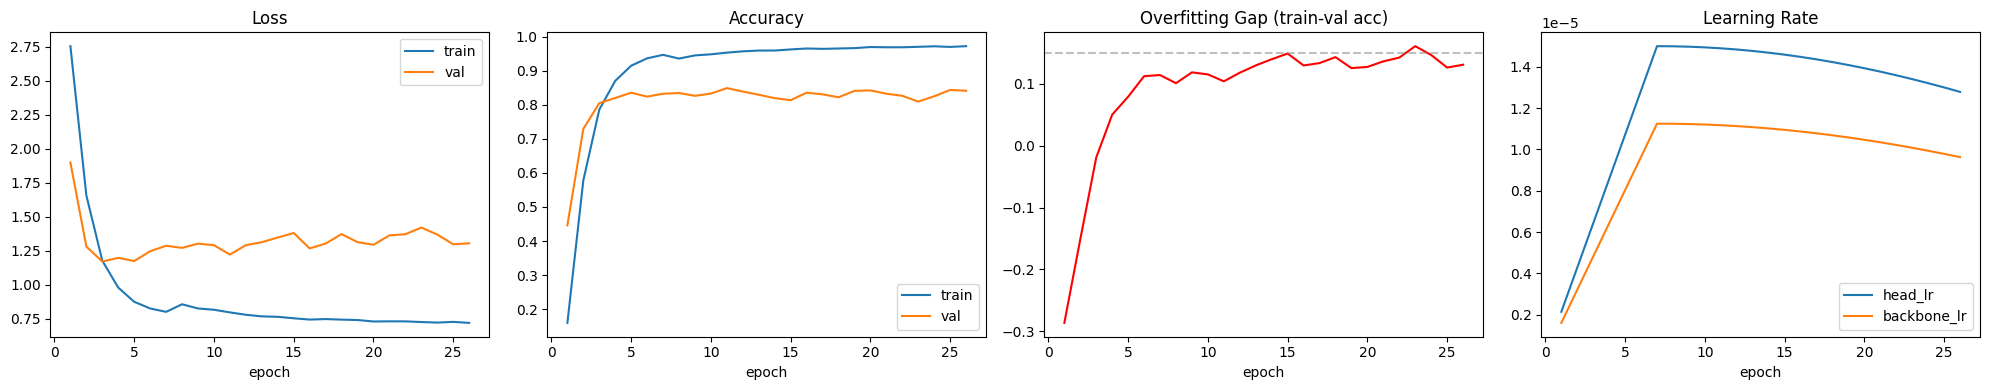

In [13]:
if not hist.empty:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    axes[0].plot(hist["epoch"], hist["train_loss"], label="train")
    axes[0].plot(hist["epoch"], hist["val_loss"], label="val")
    axes[0].legend(); axes[0].set_title("Loss"); axes[0].set_xlabel("epoch")

    axes[1].plot(hist["epoch"], hist["train_acc"], label="train")
    axes[1].plot(hist["epoch"], hist["val_acc"], label="val")
    axes[1].legend(); axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch")

    axes[2].plot(hist["epoch"], hist["train_acc"] - hist["val_acc"], color="red")
    axes[2].set_title("Overfitting Gap (train-val acc)"); axes[2].set_xlabel("epoch")
    axes[2].axhline(y=0.15, color="gray", linestyle="--", alpha=0.5)

    axes[3].plot(hist["epoch"], hist["head_lr"], label="head_lr")
    axes[3].plot(hist["epoch"], hist["backbone_lr"], label="backbone_lr")
    axes[3].legend(); axes[3].set_title("Learning Rate"); axes[3].set_xlabel("epoch")

    plt.tight_layout()
    plt.show()

## 11) Best-model evaluation

/tmp/ipykernel_1404/3774937895.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Trainable: 19,253,172 / 21,074,748


val eval: 100%|██████████| 1009/1009 [00:18<00:00, 55.29it/s]


Accuracy: 0.8493
Macro F1: 0.8390

Classification report:

                          precision    recall  f1-score   support

           C1_Drive_Safe     0.6225    0.5166    0.5646       664
                C2_Sleep     0.7988    0.4219    0.5521       640
              C3_Yawning     0.8865    0.9737    0.9281       457
            C4_Talk_Left     0.9705    0.9412    0.9556       629
           C5_Talk_Right     0.8838    0.7875    0.8329       560
            C6_Text_Left     0.8959    0.8283    0.8608       530
           C7_Text_Right     0.8643    0.8979    0.8808       617
              C8_Make_Up     0.9231    0.9884    0.9546       692
            C9_Look_Left     0.9795    0.9896    0.9845       579
          C10_Look_Right     0.7874    0.8795    0.8309       581
             C11_Look_Up     0.9881    0.9784    0.9833       510
           C12_Look_Down     0.7728    0.9419    0.8490       585
          C13_Smoke_Left     0.9705    0.8974    0.9326       624
         C14_Smo

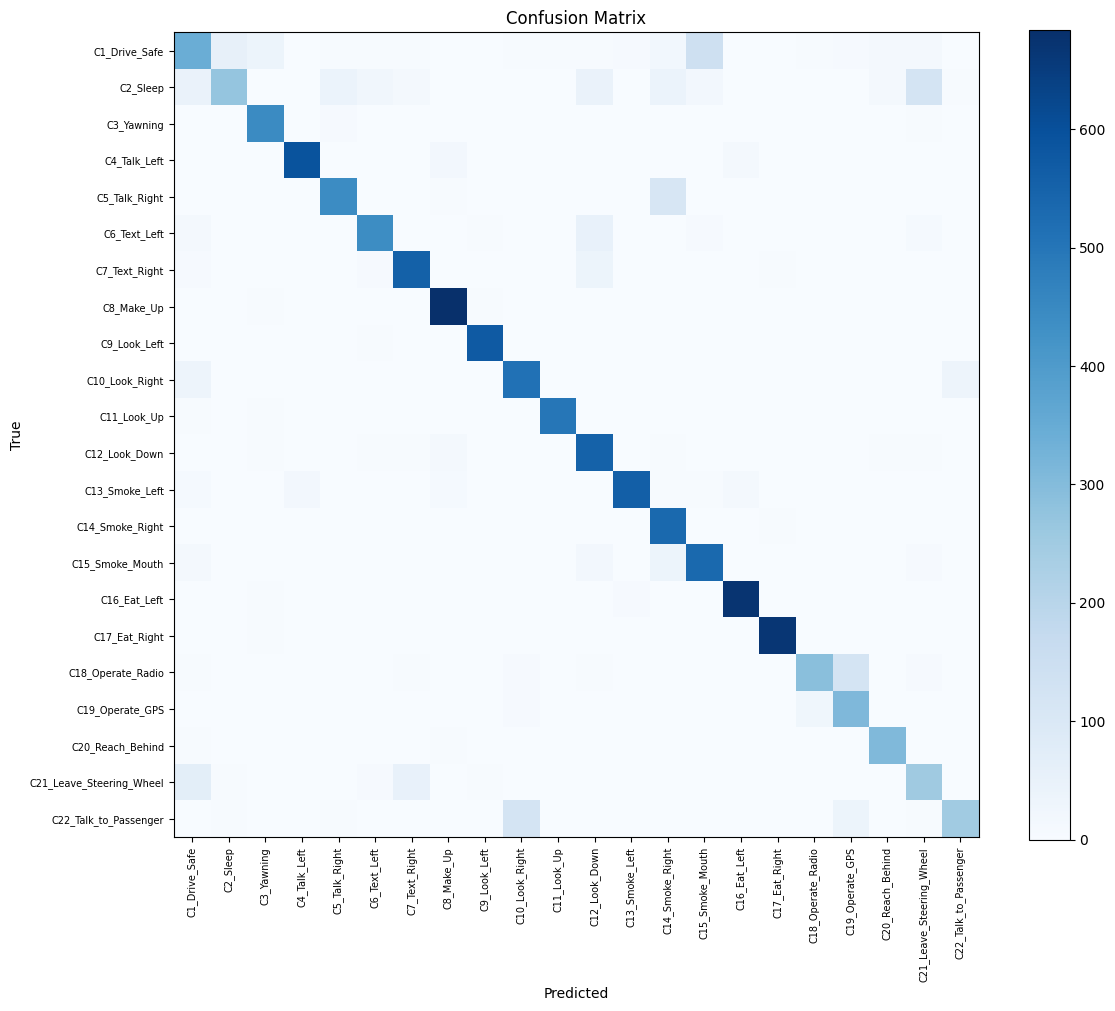

In [14]:
best_model = build_model(NUM_CLASSES, device)
state_dict = torch.load(best_path, map_location=device)
best_model.load_state_dict(state_dict)
best_model = best_model.to(device).eval()

y_true_all, y_pred_all = [], []
with torch.no_grad():
    for batch in tqdm(val_loader, desc="val eval"):
        (images, geo, gv), labels = batch
        images = images.to(device, non_blocking=True)
        geo = geo.to(device, non_blocking=True)
        gv = gv.to(device, non_blocking=True)
        logits = best_model(images, geo, gv)
        y_pred_all.append(logits.argmax(1).cpu().numpy())
        y_true_all.append(labels.numpy())

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

print(f"Accuracy: {accuracy_score(y_true_all, y_pred_all):.4f}")
print(f"Macro F1: {f1_score(y_true_all, y_pred_all, average='macro'):.4f}")
print("\nClassification report:\n")
print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
ticks = np.arange(len(CLASS_NAMES))
plt.xticks(ticks, CLASS_NAMES, rotation=90, fontsize=7)
plt.yticks(ticks, CLASS_NAMES, fontsize=7)
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## 12) Quick inference preview

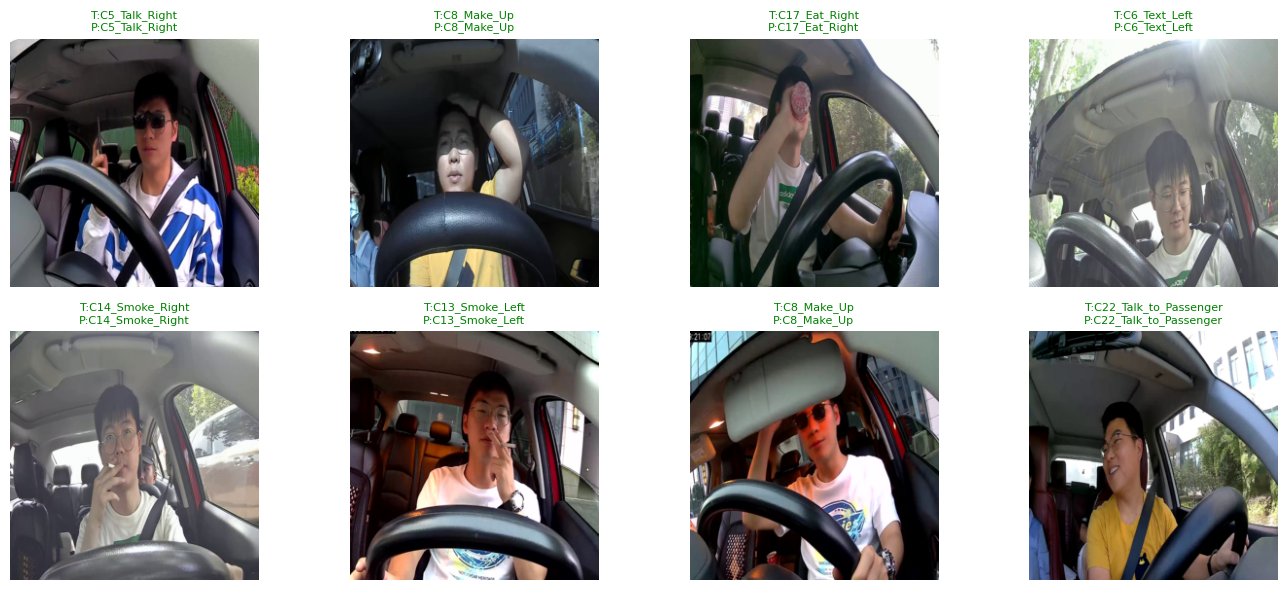

In [15]:
def denorm(x, mean, std):
    return (x * torch.tensor(std).view(3,1,1)) + torch.tensor(mean).view(3,1,1)

best_model.eval()
n = min(8, len(val_ds))
idx = np.random.choice(len(val_ds), size=n, replace=False)
samples = [val_ds[i] for i in idx]

xb = torch.stack([s[0][0] for s in samples]).to(device)
gb = torch.stack([s[0][1] for s in samples]).to(device)
gvb = torch.stack([s[0][2] for s in samples]).to(device)
yb = np.array([s[1] for s in samples])

with torch.no_grad():
    pred = best_model(xb, gb, gvb).argmax(1).cpu().numpy()

plt.figure(figsize=(14, 6))
for i in range(n):
    ax = plt.subplot(2, math.ceil(n/2), i+1)
    img = denorm(samples[i][0][0].cpu(), mean, std).clamp(0,1)
    ax.imshow(img.permute(1,2,0))
    ax.axis("off")
    color = "green" if pred[i] == yb[i] else "red"
    ax.set_title(f"T:{CLASS_NAMES[yb[i]]}\nP:{CLASS_NAMES[pred[i]]}", fontsize=8, color=color)
plt.tight_layout()
plt.show()